### Training MNIST from scratch 

1) Data loading and preprocessing

2) Creating model

3) Training loop

4) Validation loop

5) Testing

#### Data loading and visualization

In [116]:
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torchvision.transforms import Compose, \
        Normalize, ToTensor, Resize
import torch


In [117]:
# MNIST dataset 
val_frac = 0.2

transform = Compose([Resize(32), ToTensor(), 
                     Normalize((0.1307,), (0.3081,))]) # normalization for MNIST
train_dataset = MNIST("data", True, transform, download=True)

generator = torch.Generator().manual_seed(3141)
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [1-val_frac, val_frac], generator=generator)

test_dataset = MNIST("data", False, transform, download=True)



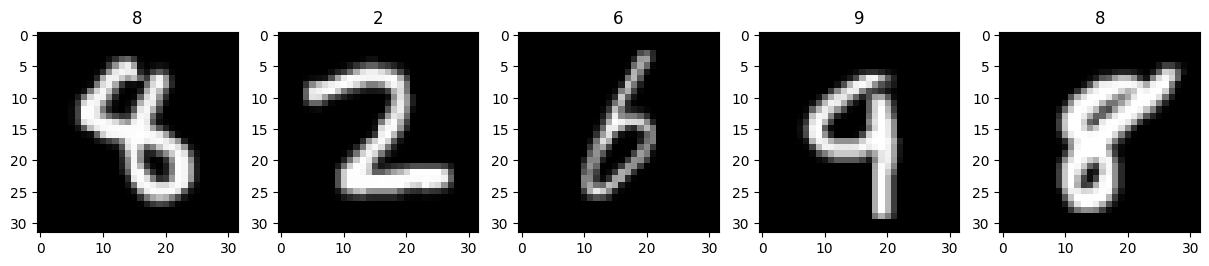

In [118]:
# Visualize our dataset
import matplotlib.pyplot as plt

def show_imgs(num_imgs, dataset):

    plt.figure(figsize=(num_imgs*3, 3))

    iter_ds = iter(dataset)
    for img in range(1,num_imgs+1):
        x, y = next(iter_ds)

        plt.subplot(1, num_imgs, img)
        plt.imshow(x.squeeze(), cmap='gray')
        plt.title(y)

show_imgs(5, train_dataset)

#### Model architecture: LeNet

In [119]:
import torch.nn.functional as F
import torch.nn as nn 

class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel (black & white), 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension
        self.fc_secondlast = nn.Linear(120, 512)
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc_secondlast(x))
        x = self.fc(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

#### Training loop

In [28]:
# Create dataloader (which we need in the training loop)
# Need to specify batch size
batch_size = 128

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, 
                        batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=batch_size, shuffle=True)

In [30]:
def accuracy(out, yb):
    '''
    calculates the accuracy based on the predicted outputs and true labels y

    out: predicted output
    yb: true labels y
    '''
    preds = torch.argmax(out, axis=1)
    acc = (preds == yb).float().mean()
    
    return acc


In [61]:
import torch.optim as optim
import pandas as pd 


## Create model
model = LeNet()

# Create optimizer
lr = 0.002
momentum = 0.9
optimizer = optim.SGD(model.parameters(), lr, momentum)

n_epochs = 20
total_step = len(train_loader)
device = 'cpu'
criterion = nn.CrossEntropyLoss()

step = 0
df = pd.DataFrame({'step':[], 'mb_loss':[], 'mb_acc':[], 
                   'val_loss':[], 'val_acc':[]})

for epoch in range(n_epochs):
    
    model.train()


    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if i % 20 == 0:
            df.loc[len(df)] = [step, loss.item(), 
                               accuracy(logits, labels).item(), 
                               float('NaN'), float('NaN')]
            if i % 100 == 0:
                print(f"Epoch [{epoch+1}/{n_epochs}], \
                Step [{i+1}/{total_step}], Loss: {loss.item():.4f}, \
                Acc: {accuracy(logits, labels).item():.4f}, LR: {lr}")
                epoch_val_loss, epoch_val_acc = valid_loop(model, val_loader)

                df.loc[len(df)-1] = [step, loss.item(), 
                                     accuracy(logits, labels).item(), 
                                     epoch_val_loss, epoch_val_acc]

        step += 1

Epoch [1/20], Step [1/375], Loss: 2.2959, Acc: 0.2031, LR: 0.002
Validation accuracy: 18.18%, validation loss: 2.3015
Epoch [1/20], Step [101/375], Loss: 2.1857, Acc: 0.4297, LR: 0.002
Validation accuracy: 46.49%, validation loss: 2.1838
Epoch [1/20], Step [201/375], Loss: 0.5247, Acc: 0.8594, LR: 0.002
Validation accuracy: 81.89%, validation loss: 0.5600
Epoch [1/20], Step [301/375], Loss: 0.2359, Acc: 0.9375, LR: 0.002
Validation accuracy: 90.00%, validation loss: 0.3266
Epoch [2/20], Step [1/375], Loss: 0.3037, Acc: 0.9297, LR: 0.002
Validation accuracy: 91.55%, validation loss: 0.2831
Epoch [2/20], Step [101/375], Loss: 0.2169, Acc: 0.9219, LR: 0.002
Validation accuracy: 93.01%, validation loss: 0.2348
Epoch [2/20], Step [201/375], Loss: 0.1600, Acc: 0.9375, LR: 0.002
Validation accuracy: 94.78%, validation loss: 0.1759
Epoch [2/20], Step [301/375], Loss: 0.0891, Acc: 0.9766, LR: 0.002
Validation accuracy: 95.05%, validation loss: 0.1656
Epoch [3/20], Step [1/375], Loss: 0.1108, Ac

Text(0, 0.5, 'Accuracy')

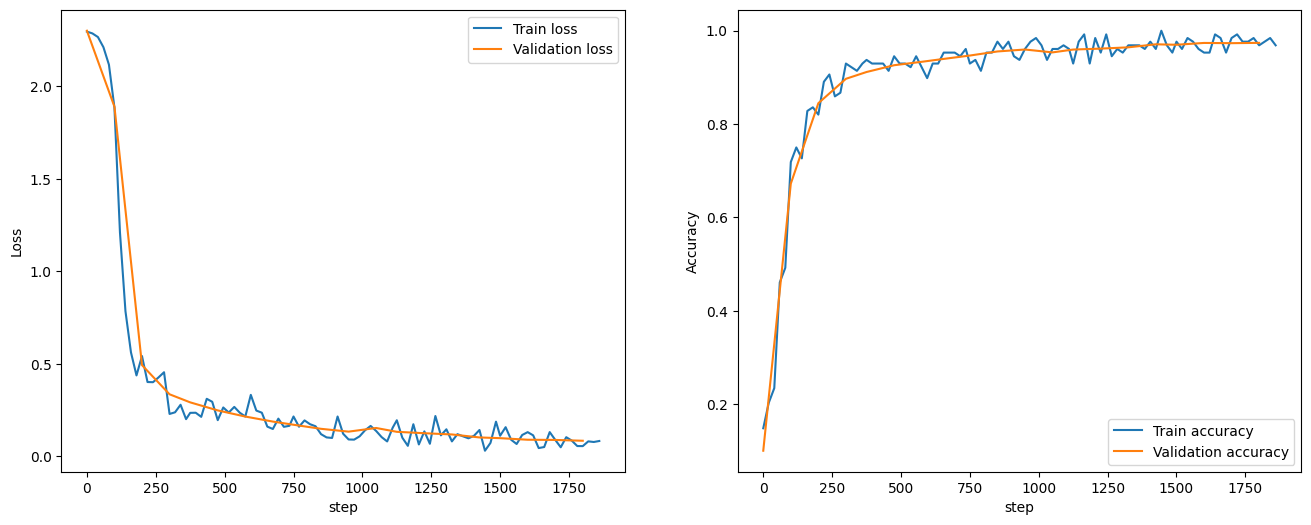

In [60]:
# Plot training loss and training accuracy
import seaborn as sns

plt.figure(figsize=(16,6))

plt.subplot(121)

sns.lineplot(df, x='step', y='mb_loss', label='Train loss')
sns.lineplot(df, x='step', y='val_loss', label='Validation loss')

plt.ylabel('Loss')
# plt.legend()

plt.subplot(122)
sns.lineplot(df, x='step', y='mb_acc', label='Train accuracy')
sns.lineplot(df, x='step', y='val_acc', label='Validation accuracy')

plt.ylabel('Accuracy')


In [51]:
# Validation loop

def valid_loop(model, val_loader):
    # Accumulators
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for i, (images, labels) in enumerate(val_loader):
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        # ---- Accumulate training loss ----
        # Multiply by the batch size so we have the total loss for these samples
        running_loss += loss.item() * images.size(0)

        # ---- Accumulate training accuracy ----
        # Use your accuracy() function or do an equivalent inline
        batch_acc = accuracy(logits, labels)  
        running_correct += batch_acc.item() * images.size(0)

        # Track how many total samples we've seen
        total_samples += images.size(0)

    epoch_val_loss = running_loss / total_samples
    epoch_val_acc = running_correct / total_samples

    print(f'Validation accuracy: {100*epoch_val_acc:.2f}%, validation loss: {epoch_val_loss:.4f}')

    return epoch_val_loss, epoch_val_acc


In [59]:
# Test loop


# Accumulators
running_loss = 0.0
running_correct = 0
total_samples = 0

for i, (images, labels) in enumerate(test_loader):
    images, labels = images.to(device), labels.to(device)

    logits = model(images)
    loss = criterion(logits, labels)

    # ---- Accumulate test loss ----
    # Multiply by the batch size so we have the total loss for these samples
    running_loss += loss.item() * images.size(0)

    # ---- Accumulate test accuracy ----
    # Use your accuracy() function or do an equivalent inline
    batch_acc = accuracy(logits, labels)  
    running_correct += batch_acc.item() * images.size(0)

    # Track how many total samples we've seen
    total_samples += images.size(0)

epoch_test_loss = running_loss / total_samples
epoch_test_acc = running_correct / total_samples

print(f'Test accuracy: {100*epoch_val_acc:.2f}%, test loss: {epoch_val_loss:.4f}')


Test accuracy: 97.40%, test loss: 0.0844


4
tensor([9, 6, 9, 1])


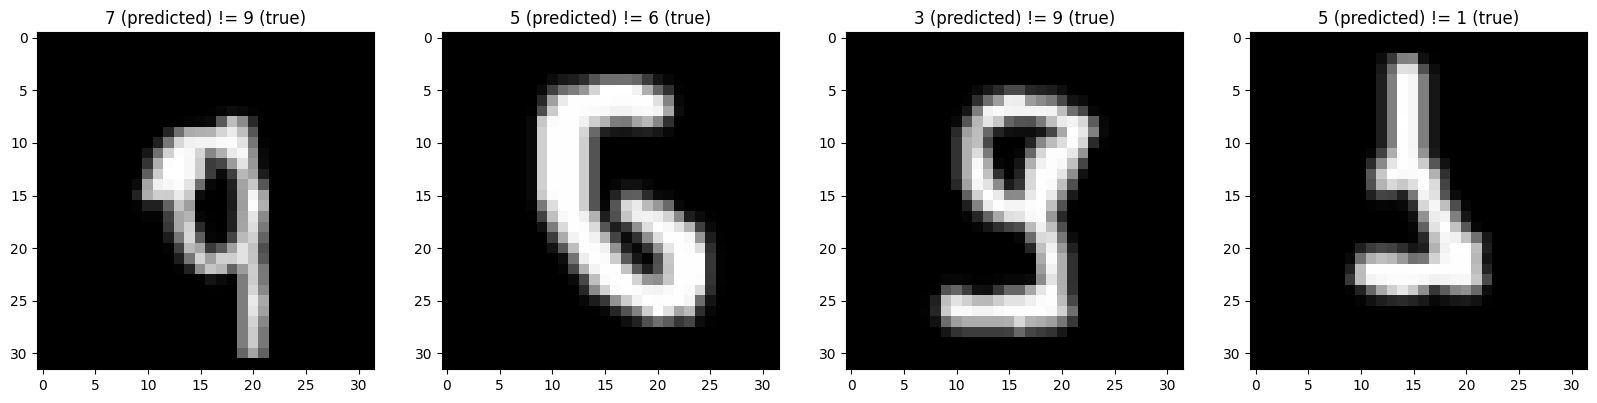

In [120]:
# Show some wrongly classified images

for i, (images, labels) in enumerate(test_loader):
    images, labels = images.to(device), labels.to(device)

    logits = model(images)

    print(sum(~(torch.argmax(logits, axis=1)== labels)).item())

    num_wrongly_classified_imgs = sum(~(torch.argmax(logits, axis=1)== labels)).item()

    if num_wrongly_classified_imgs > 0:

        print(labels[~(torch.argmax(logits, axis=1)== labels)])
        wrongly_classified_labels = torch.argmax(logits, 
                                                 axis=1)[~(torch.argmax(logits, axis=1)== labels)]
        true_classified_labels = labels[~(torch.argmax(logits, axis=1)== labels)]
        wrongly_classified_imgs = images[~(torch.argmax(logits, axis=1)== labels),:,:,:].squeeze()
        
        if num_wrongly_classified_imgs == 1:
            plt.imshow(wrongly_classified_imgs, cmap='gray')
            plt.title(f'{wrongly_classified_labels[0].item()} != {true_classified_labels[0].item()}')
        else:
            plt.figure(figsize=(num_wrongly_classified_imgs*5, 5))
            for img in range(1, num_wrongly_classified_imgs+1):
                plt.subplot(1,num_wrongly_classified_imgs, img)

                plt.imshow(wrongly_classified_imgs[img-1, :, :], cmap='gray')
                plt.title(f'{wrongly_classified_labels[img-1].item()} (predicted) != {true_classified_labels[img-1].item()} (true)')
    break
